In [17]:
import tensorflow as tf
tf.__version__

'2.21.0'

In [18]:
mnist = tf.keras.datasets.mnist # 28x28 hand writen digits from 0 - 9

In [19]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [20]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

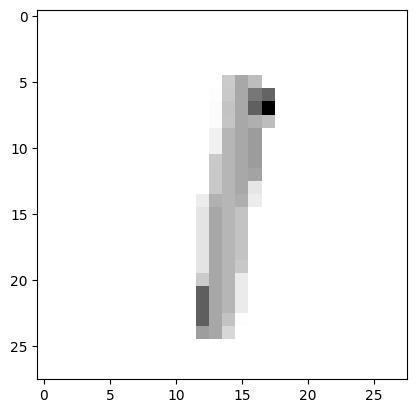

In [21]:
print(x_train[10])
import matplotlib.pyplot as plt
plt.imshow(x_train[40] , cmap= plt.cm.binary)
print(y_train[40])

In [22]:
import tensorflow as tf
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(128, activation=tf.keras.layers.LeakyReLU(alpha=0.1)))

model.add(tf.keras.layers.Dense(10, activation=tf.nn.softmax))

In [23]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) 

In [24]:
history = model.fit(x_train, y_train, epochs=5, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1)], validation_data=(x_train, y_train))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9198 - loss: 0.2666 - val_accuracy: 0.9649 - val_loss: 0.1135
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9629 - loss: 0.1187 - val_accuracy: 0.9763 - val_loss: 0.0775
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9717 - loss: 0.0907 - val_accuracy: 0.9842 - val_loss: 0.0517
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9766 - loss: 0.0722 - val_accuracy: 0.9862 - val_loss: 0.0437
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9798 - loss: 0.0617 - val_accuracy: 0.9896 - val_loss: 0.0330


In [25]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(val_loss, val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0865
0.08648829907178879 0.9751999974250793


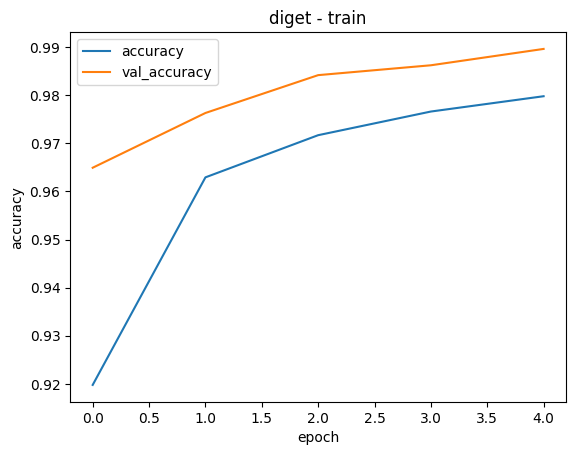

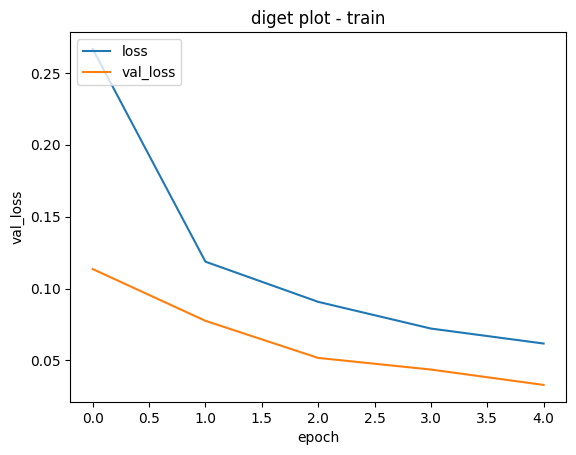

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('diget - train')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('diget plot - train')
plt.ylabel('val_loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='upper left')
plt.show()

In [27]:
model.save('num.keras')

In [28]:
model.load_weights('num.keras')

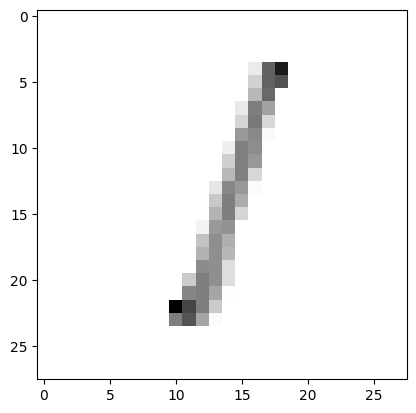

In [34]:
plt.imshow(x_test[2], cmap= plt.cm.binary)

In [31]:
predictions = model.predict([x_test])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [33]:
import numpy as np
print(np.argmax(predictions[2]))

1
